# E-Commerce Return Rate Reduction Analysis

## Objective

The objective of this project is to analyze e-commerce return patterns and identify the factors associated with product returns. The analysis uses Python, SQL, Machine Learning, and Power BI to:

- Analyze return rates across product categories, locations, shipping methods, and return reasons.
- Identify patterns that may contribute to higher return rates.
- Build a Logistic Regression model to estimate the probability of an order being returned.
- Generate return risk scores and identify high-risk products.
- Create an interactive Power BI dashboard to support return-rate monitoring and business decision-making.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("returns_sustainability_dataset.csv")

df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,...,Return_Status,Return_Reason,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,...,Not Returned,No Return,0,2393.163468,0,2393.163468,2.0,0.4,2.0,0.4
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,...,Returned,Size Issue,12,2618.347140,200,2418.347140,2.0,1.0,0.0,0.0
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,...,Not Returned,No Return,0,2567.404800,0,2567.404800,1.5,1.0,1.5,1.0
3,ORD00003,PROD0323,USER1274,2024-11-06,Books,1855.65,2,2.90,Express,COD,...,Not Returned,No Return,0,3603.672300,0,3603.672300,1.5,0.4,1.5,0.4
4,ORD00004,PROD0325,USER0551,2023-06-07,Home Appliances,1770.97,5,44.42,Express,COD,...,Returned,Size Issue,11,4921.525630,200,4721.525630,1.5,1.0,0.0,0.0


In [2]:
df.shape

(5000, 23)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          5000 non-null   object 
 1   Product_ID        5000 non-null   object 
 2   User_ID           5000 non-null   object 
 3   Order_Date        5000 non-null   object 
 4   Product_Category  5000 non-null   object 
 5   Product_Price     5000 non-null   float64
 6   Order_Quantity    5000 non-null   int64  
 7   Discount_Applied  5000 non-null   float64
 8   Shipping_Method   5000 non-null   object 
 9   Payment_Method    5000 non-null   object 
 10  User_Age          5000 non-null   int64  
 11  User_Gender       5000 non-null   object 
 12  User_Location     5000 non-null   object 
 13  Return_Status     5000 non-null   object 
 14  Return_Reason     5000 non-null   object 
 15  Days_to_Return    5000 non-null   int64  
 16  Order_Value       5000 non-null   float64


In [4]:
df.isnull().sum()

Order_ID            0
Product_ID          0
User_ID             0
Order_Date          0
Product_Category    0
Product_Price       0
Order_Quantity      0
Discount_Applied    0
Shipping_Method     0
Payment_Method      0
User_Age            0
User_Gender         0
User_Location       0
Return_Status       0
Return_Reason       0
Days_to_Return      0
Order_Value         0
Return_Cost         0
Profit_Loss         0
CO2_Emissions       0
Packaging_Waste     0
CO2_Saved           0
Waste_Avoided       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Return_Status"].value_counts()

Return_Status
Not Returned    3550
Returned        1450
Name: count, dtype: int64

In [7]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [8]:
df["Order_Date"].dtype

dtype('<M8[ns]')

In [9]:
print("Product Categories:")
print(df["Product_Category"].value_counts())

print("\nReturn Reasons:")
print(df["Return_Reason"].value_counts())

print("\nShipping Methods:")
print(df["Shipping_Method"].value_counts())

print("\nPayment Methods:")
print(df["Payment_Method"].value_counts())

Product Categories:
Product_Category
Clothing           1766
Electronics        1244
Books               762
Toys                752
Home Appliances     476
Name: count, dtype: int64

Return Reasons:
Return_Reason
No Return       3550
Defective        382
Changed Mind     379
Wrong Item       348
Size Issue       341
Name: count, dtype: int64

Shipping Methods:
Shipping_Method
Next-Day    1684
Standard    1683
Express     1633
Name: count, dtype: int64

Payment Methods:
Payment_Method
Debit Card     1277
Wallet         1275
Credit Card    1235
COD            1213
Name: count, dtype: int64


In [10]:
return_counts = df["Return_Status"].value_counts()

return_rate = (
    df["Return_Status"].eq("Returned").mean() * 100
)

print("Total Orders:", len(df))
print("Returned Orders:", return_counts["Returned"])
print("Not Returned Orders:", return_counts["Not Returned"])
print("Return Rate: {:.2f}%".format(return_rate))


Total Orders: 5000
Returned Orders: 1450
Not Returned Orders: 3550
Return Rate: 29.00%


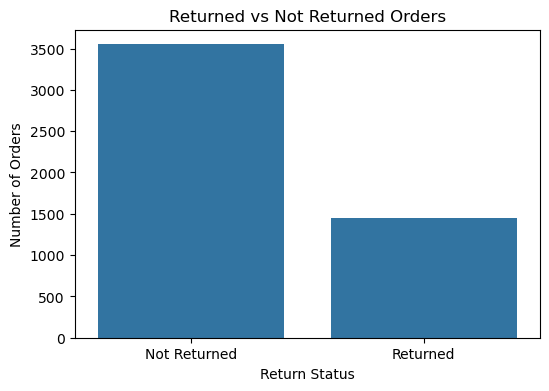

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Return_Status"
)

plt.title("Returned vs Not Returned Orders")
plt.xlabel("Return Status")
plt.ylabel("Number of Orders")
plt.show()

In [12]:
category_return_rate = (
    df.groupby("Product_Category")["Return_Status"]
    .apply(lambda x: (x == "Returned").mean() * 100)
    .sort_values(ascending=False)
)

category_return_rate

Product_Category
Clothing           37.429219
Home Appliances    25.630252
Electronics        25.241158
Toys               24.069149
Books              22.572178
Name: Return_Status, dtype: float64

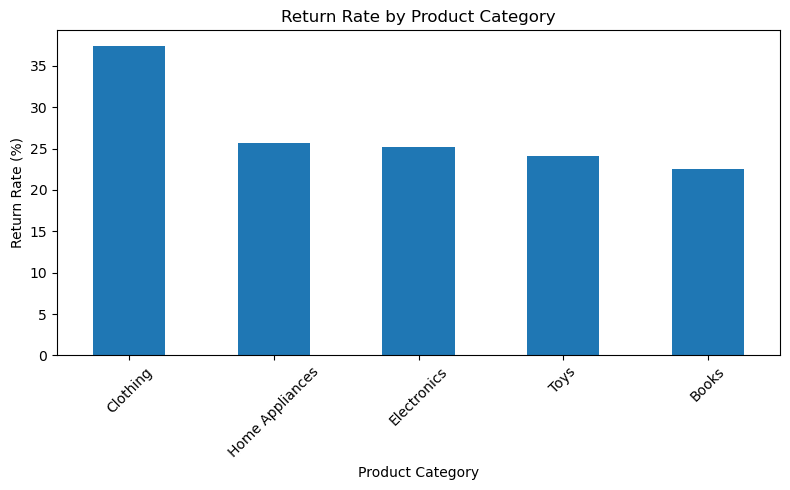

In [13]:
plt.figure(figsize=(8, 5))

category_return_rate.plot(kind="bar")

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
print("Return Rate by Product Category:")
print(category_return_rate.round(2))

Return Rate by Product Category:
Product_Category
Clothing           37.43
Home Appliances    25.63
Electronics        25.24
Toys               24.07
Books              22.57
Name: Return_Status, dtype: float64


In [15]:
location_return_rate = (
    df.groupby("User_Location")["Return_Status"]
    .apply(lambda x: (x == "Returned").mean() * 100)
    .sort_values(ascending=False)
)

print("Return Rate by Location:")
print(location_return_rate.round(2))

Return Rate by Location:
User_Location
City44    50.00
City85    43.90
City77    43.18
City55    42.00
City58    42.00
          ...  
City37    18.46
City83    15.56
City66    15.52
City79    14.58
City50    13.73
Name: Return_Status, Length: 100, dtype: float64


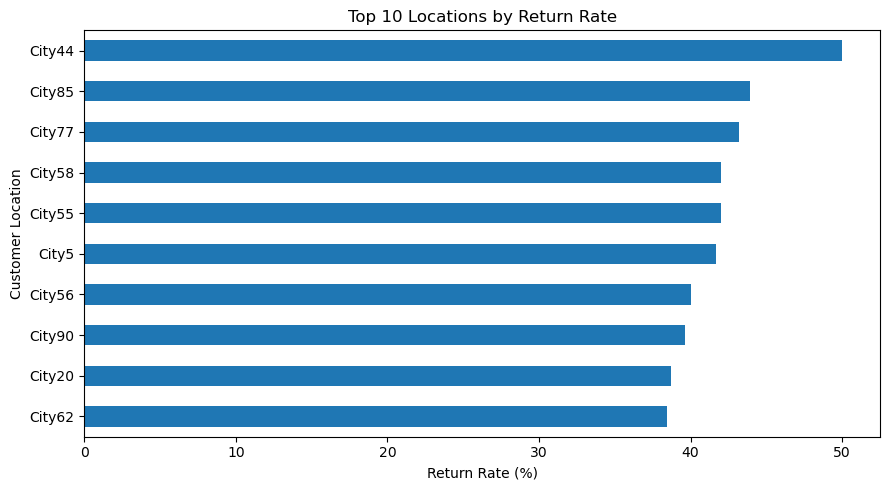

In [17]:
top_locations = location_return_rate.head(10)

plt.figure(figsize=(9, 5))

top_locations.sort_values().plot(kind="barh")

plt.title("Top 10 Locations by Return Rate")
plt.xlabel("Return Rate (%)")
plt.ylabel("Customer Location")
plt.tight_layout()
plt.show()

In [18]:
print("Top 10 Locations by Return Rate:")
print(top_locations.round(2))

Top 10 Locations by Return Rate:
User_Location
City44    50.00
City85    43.90
City77    43.18
City55    42.00
City58    42.00
City5     41.67
City56    40.00
City90    39.62
City20    38.71
City62    38.46
Name: Return_Status, dtype: float64


In [19]:
return_reasons = (
    df[df["Return_Status"] == "Returned"]["Return_Reason"]
    .value_counts()
)

print("Return Reasons:")
print(return_reasons)

Return Reasons:
Return_Reason
Defective       382
Changed Mind    379
Wrong Item      348
Size Issue      341
Name: count, dtype: int64


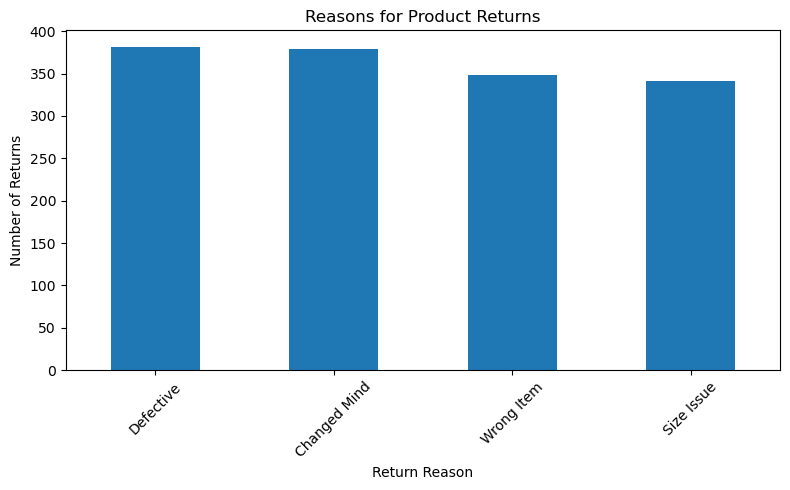

In [20]:
plt.figure(figsize=(8, 5))

return_reasons.plot(kind="bar")

plt.title("Reasons for Product Returns")
plt.xlabel("Return Reason")
plt.ylabel("Number of Returns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
shipping_return_rate = (
    df.groupby("Shipping_Method")["Return_Status"]
    .apply(lambda x: (x == "Returned").mean() * 100)
    .sort_values(ascending=False)
)

print("Return Rate by Shipping Method:")
print(shipping_return_rate.round(2))

Return Rate by Shipping Method:
Shipping_Method
Standard    29.41
Express     29.09
Next-Day    28.50
Name: Return_Status, dtype: float64


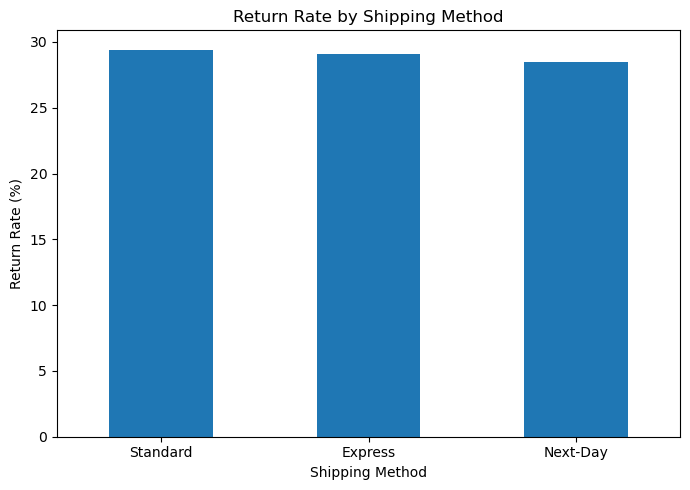

In [22]:
plt.figure(figsize=(7, 5))

shipping_return_rate.plot(kind="bar")

plt.title("Return Rate by Shipping Method")
plt.xlabel("Shipping Method")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
df["Discount_Range"] = pd.cut(
    df["Discount_Applied"],
    bins=[0, 10, 20, 30, 40, 50],
    labels=["0-10", "10-20", "20-30", "30-40", "40-50"],
    include_lowest=True
)

In [24]:
discount_return_rate = (
    df.groupby("Discount_Range", observed=False)["Return_Status"]
    .apply(lambda x: (x == "Returned").mean() * 100)
)

print("Return Rate by Discount Range:")
print(discount_return_rate.round(2))

Return Rate by Discount Range:
Discount_Range
0-10     24.05
10-20    26.87
20-30    25.90
30-40    35.21
40-50    33.30
Name: Return_Status, dtype: float64


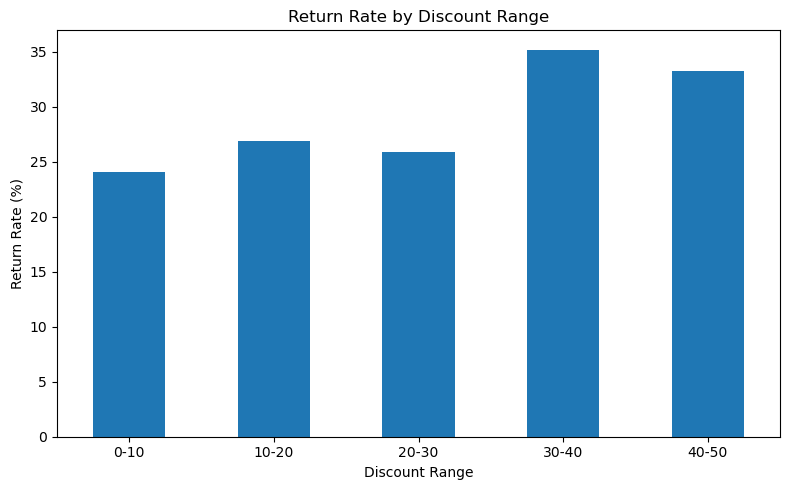

In [25]:
plt.figure(figsize=(8, 5))

discount_return_rate.plot(kind="bar")

plt.title("Return Rate by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# 1. Discount vs Return Rate

df["Discount_Range"] = pd.cut(
    df["Discount_Applied"],
    bins=[0, 10, 20, 30, 40, 50],
    labels=["0-10", "10-20", "20-30", "30-40", "40-50"],
    include_lowest=True
)

discount_return_rate = (
    df.groupby("Discount_Range", observed=False)["Return_Status"]
    .apply(lambda x: (x == "Returned").mean() * 100)
)

print("Return Rate by Discount Range:")
print(discount_return_rate.round(2))


# 2. Return Rate by Order Value

df["Order_Value_Range"] = pd.qcut(
    df["Order_Value"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

order_value_return_rate = (
    df.groupby("Order_Value_Range", observed=False)["Return_Status"]
    .apply(lambda x: (x == "Returned").mean() * 100)
)

print("\nReturn Rate by Order Value:")
print(order_value_return_rate.round(2))


# 3. Monthly Return Rate

df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

monthly_return_rate = (
    df.groupby("Month")["Return_Status"]
    .apply(lambda x: (x == "Returned").mean() * 100)
)

print("\nMonthly Return Rate:")
print(monthly_return_rate.round(2).head())

Return Rate by Discount Range:
Discount_Range
0-10     24.05
10-20    26.87
20-30    25.90
30-40    35.21
40-50    33.30
Name: Return_Status, dtype: float64

Return Rate by Order Value:
Order_Value_Range
Low          29.60
Medium       29.12
High         28.80
Very High    28.48
Name: Return_Status, dtype: float64

Monthly Return Rate:
Month
2022-01    27.27
2022-02    28.83
2022-03    21.57
2022-04    28.81
2022-05    25.62
Name: Return_Status, dtype: float64


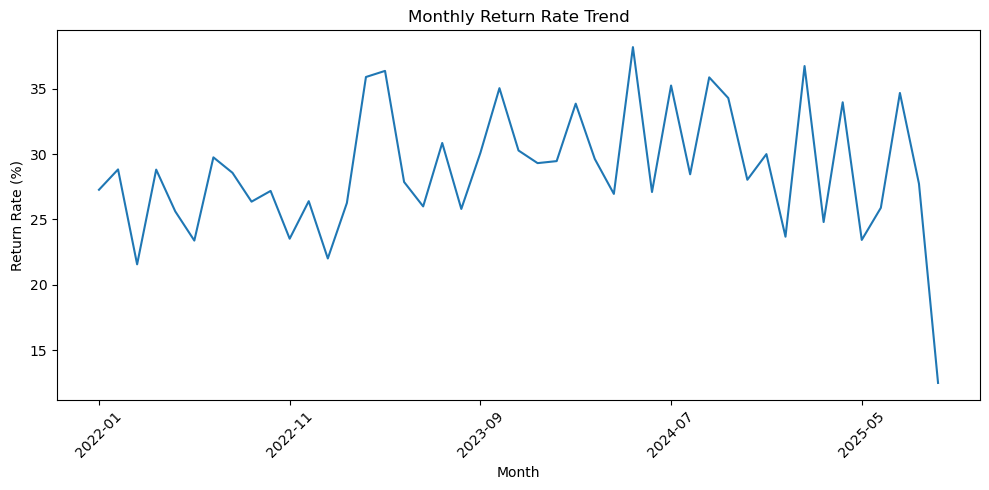

In [27]:
plt.figure(figsize=(10, 5))

monthly_return_rate.plot()

plt.title("Monthly Return Rate Trend")
plt.xlabel("Month")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Target
y = (df["Return_Status"] == "Returned").astype(int)

# Features available before/at the time of order
features = [
    "Product_Category",
    "Product_Price",
    "Order_Quantity",
    "Discount_Applied",
    "Shipping_Method",
    "Payment_Method",
    "User_Age",
    "User_Gender",
    "User_Location",
    "Order_Value",
    "CO2_Emissions",
    "Packaging_Waste"
]

X = df[features]

# Identify categorical and numerical columns
categorical_features = [
    "Product_Category",
    "Shipping_Method",
    "Payment_Method",
    "User_Gender",
    "User_Location"
]

numerical_features = [
    "Product_Price",
    "Order_Quantity",
    "Discount_Applied",
    "User_Age",
    "Order_Value",
    "CO2_Emissions",
    "Packaging_Waste"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred = logistic_model.predict(X_test)
y_probability = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_probability), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.703
ROC-AUC: 0.5948

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.98      0.82       710
           1       0.36      0.03      0.06       290

    accuracy                           0.70      1000
   macro avg       0.54      0.50      0.44      1000
weighted avg       0.61      0.70      0.60      1000


Confusion Matrix:
[[694  16]
 [281   9]]


In [29]:
# Predict return probability for all orders
df["Return_Risk_Score"] = logistic_model.predict_proba(X)[:, 1]

# Product-level analysis
product_risk = (
    df.groupby("Product_ID")
    .agg(
        Total_Orders=("Order_ID", "count"),
        Returned_Orders=("Return_Status", lambda x: (x == "Returned").sum()),
        Return_Rate=("Return_Status", lambda x: (x == "Returned").mean() * 100),
        Average_Risk_Score=("Return_Risk_Score", "mean"),
        Average_Order_Value=("Order_Value", "mean")
    )
    .reset_index()
)

# Consider products with at least 5 orders
product_risk = product_risk[
    product_risk["Total_Orders"] >= 5
]

# Sort by risk score
high_risk_products = product_risk.sort_values(
    "Average_Risk_Score",
    ascending=False
)

high_risk_products.head(20)

,Product_ID,Total_Orders,Returned_Orders,Return_Rate,Average_Risk_Score,Average_Order_Value
376,PROD0377,10,3,30.000000,0.383913,1974.346261
51,PROD0052,12,4,33.333333,0.363800,3079.306241
449,PROD0450,6,3,50.000000,0.363290,3207.450731
31,PROD0032,10,3,30.000000,0.359891,2030.466038
381,PROD0382,7,1,14.285714,0.359715,1950.317220
284,PROD0285,9,5,55.555556,0.357438,3020.108976
417,PROD0418,10,2,20.000000,0.357045,1748.134211
188,PROD0189,6,0,0.000000,0.356836,1978.630902
468,PROD0469,6,3,50.000000,0.354929,2707.236036
315,PROD0316,12,3,25.000000,0.354287,1209.511902


In [30]:
high_risk_products.head(20).to_csv(
    "High_Risk_Products.csv",
    index=False
)

print("High-risk products exported successfully.")


High-risk products exported successfully.
